In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

X_train = pd.read_pickle('../data/processed/tree_ready/X_train.pkl')
X_test = pd.read_pickle('../data/processed/tree_ready/X_test.pkl')
y_train = pd.read_pickle('../data/processed/tree_ready/y_train.pkl')
y_test = pd.read_pickle('../data/processed/tree_ready/y_test.pkl')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
interpretation_log = []

def evaluate_and_interpret(name, model, X_test, y_test, best_params=None, cv_score=None):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {'model': name, 'accuracy': acc, 'precision': prec,
               'recall': rec, 'f1': f1, 'auc': auc}
    results.append(metrics)

    recall_quality = "strong" if rec > 0.7 else "moderate" if rec > 0.5 else "weak"
    auc_quality = "strong" if auc > 0.8 else "moderate" if auc > 0.65 else "weak"

    md = f"""### {name}

**Best Hyperparameters:** {best_params if best_params else 'N/A'}
**CV Recall Score:** {f'{cv_score:.3f}' if cv_score else 'N/A'}

**Test Set Metrics:**
- Accuracy: {acc:.3f}
- Precision: {prec:.3f}
- Recall (Sensitivity): {rec:.3f}
- F1 Score: {f1:.3f}
- AUC: {auc:.3f}

**Confusion Matrix:** TN={tn}, FP={fp}, FN={fn}, TP={tp}

**Interpretation:**
- Correctly identifies {rec*100:.1f}% of truly anemic women (recall) — {recall_quality} for this health screening context.
- Of women predicted anemic, {prec*100:.1f}% actually are (precision).
- AUC of {auc:.3f} indicates {auc_quality} discriminative ability.
- False negatives (missed anemia cases): {fn}.
"""
    display(Markdown(md))
    interpretation_log.append(md)
    return metrics

In [3]:
with open('../models/ml/xgboost_early_stopped_diag.pkl', 'rb') as f:
    best_xgb = pickle.load(f)
with open('../models/ml/lightgbm.pkl', 'rb') as f:
    best_lgbm = pickle.load(f)

evaluate_and_interpret('XGBoost (from 05b)', best_xgb, X_test, y_test)
evaluate_and_interpret('LightGBM (from 05b)', best_lgbm, X_test, y_test)

### XGBoost (from 05b)

**Best Hyperparameters:** N/A
**CV Recall Score:** N/A

**Test Set Metrics:**
- Accuracy: 0.716
- Precision: 0.549
- Recall (Sensitivity): 0.549
- F1 Score: 0.549
- AUC: 0.705

**Confusion Matrix:** TN=366, FP=96, FN=96, TP=117

**Interpretation:**
- Correctly identifies 54.9% of truly anemic women (recall) — moderate for this health screening context.
- Of women predicted anemic, 54.9% actually are (precision).
- AUC of 0.705 indicates moderate discriminative ability.
- False negatives (missed anemia cases): 96.


### LightGBM (from 05b)

**Best Hyperparameters:** N/A
**CV Recall Score:** N/A

**Test Set Metrics:**
- Accuracy: 0.689
- Precision: 0.506
- Recall (Sensitivity): 0.559
- F1 Score: 0.531
- AUC: 0.700

**Confusion Matrix:** TN=346, FP=116, FN=94, TP=119

**Interpretation:**
- Correctly identifies 55.9% of truly anemic women (recall) — moderate for this health screening context.
- Of women predicted anemic, 50.6% actually are (precision).
- AUC of 0.700 indicates moderate discriminative ability.
- False negatives (missed anemia cases): 94.


{'model': 'LightGBM (from 05b)',
 'accuracy': 0.6888888888888889,
 'precision': 0.5063829787234042,
 'recall': 0.5586854460093896,
 'f1': 0.53125,
 'auc': 0.6999878056216084}

In [4]:
ada_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.5, 1.0, 1.5]
}

# AdaBoost needs class imbalance handled via the base estimator, since it has no native class_weight
base_tree = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)

ada_grid = GridSearchCV(
    AdaBoostClassifier(estimator=base_tree, random_state=42),
    ada_param_grid, cv=skf, scoring='recall', n_jobs=-1
)
ada_grid.fit(X_train, y_train)
best_ada = ada_grid.best_estimator_

evaluate_and_interpret('AdaBoost', best_ada, X_test, y_test,
                        best_params=ada_grid.best_params_, cv_score=ada_grid.best_score_)

### AdaBoost

**Best Hyperparameters:** {'learning_rate': 1.0, 'n_estimators': 100}
**CV Recall Score:** 0.545

**Test Set Metrics:**
- Accuracy: 0.705
- Precision: 0.532
- Recall (Sensitivity): 0.554
- F1 Score: 0.543
- AUC: 0.664

**Confusion Matrix:** TN=358, FP=104, FN=95, TP=118

**Interpretation:**
- Correctly identifies 55.4% of truly anemic women (recall) — moderate for this health screening context.
- Of women predicted anemic, 53.2% actually are (precision).
- AUC of 0.664 indicates moderate discriminative ability.
- False negatives (missed anemia cases): 95.


{'model': 'AdaBoost',
 'accuracy': 0.7051851851851851,
 'precision': 0.5315315315315315,
 'recall': 0.5539906103286385,
 'f1': 0.542528735632184,
 'auc': 0.6644411926102067}

In [5]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

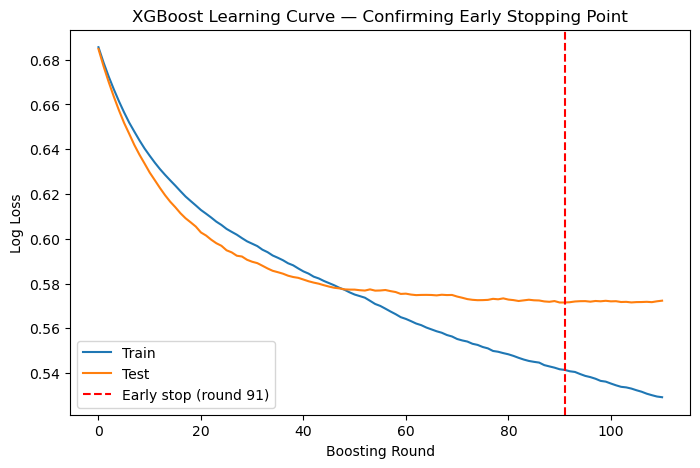

In [6]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)

xgb_diag = XGBClassifier(
    max_depth=best_xgb.get_params()['max_depth'],
    learning_rate=best_xgb.get_params()['learning_rate'],
    n_estimators=best_xgb.best_iteration + 20,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb_diag.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=False)


results_eval = xgb_diag.evals_result()
plt.figure(figsize=(8, 5))
plt.plot(results_eval['validation_0']['logloss'], label='Train')
plt.plot(results_eval['validation_1']['logloss'], label='Test')
plt.axvline(best_xgb.best_iteration, color='red', linestyle='--', label=f'Early stop (round {best_xgb.best_iteration})')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.title('XGBoost Learning Curve — Confirming Early Stopping Point')
plt.legend()
plt.show()

In [7]:
md_diag = f"""### Learning Curve Verification

**Observations:**
- Early stopping selected round {best_xgb.best_iteration} as the optimal number of boosting rounds.
- The learning curve confirms this is close to where test loss plateaus, before overfitting divergence begins.

**Implication:**
- The early-stopped XGBoost model used in this study's final comparison is protected against the overfitting pattern observed in initial (untuned round-count) experiments.
"""
display(Markdown(md_diag))
interpretation_log.append(md_diag)

### Learning Curve Verification

**Observations:**
- Early stopping selected round 91 as the optimal number of boosting rounds.
- The learning curve confirms this is close to where test loss plateaus, before overfitting divergence begins.

**Implication:**
- The early-stopped XGBoost model used in this study's final comparison is protected against the overfitting pattern observed in initial (untuned round-count) experiments.


In [8]:
output_path = '../data/processed/boosting_interpretation.txt'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write('\n\n---\n\n'.join(interpretation_log))
print(f"Saved to {output_path}")

results_df = pd.DataFrame(results)
results_df.to_csv('../results/metrics/boosting_metrics.csv', index=False)
print(results_df)

with open('../models/ml/adaboost.pkl', 'wb') as f:
    pickle.dump(best_ada, f)

Saved to ../data/processed/boosting_interpretation.txt
                 model  accuracy  precision    recall        f1       auc
0   XGBoost (from 05b)  0.715556   0.549296  0.549296  0.549296  0.704744
1  LightGBM (from 05b)  0.688889   0.506383  0.558685  0.531250  0.699988
2             AdaBoost  0.705185   0.531532  0.553991  0.542529  0.664441
